## PCA (Principal Component Analysis)

Bu bölümde, CICIDS2017 veri setindeki özellik sayısını azaltmak amacıyla Principal Component Analysis (PCA) yöntemi uygulanmıştır. PCA, verideki bilgi kaybını en aza indirerek daha az sayıda bileşen oluşturur ve boyut indirgeme işlemi gerçekleştirir.

Daha sonra PCA uygulanmış veri üzerinde Random Forest modeli eğitilerek performansı orijinal veri ile karşılaştırılmıştır.

Bizim verimizdeki 78 özellikten bazısı **tekrarlı bilgi** taşıyabilir.
PCA'nın amacı: bilgiyi mümkün olduğunca koruyarak özellik sayısını azaltmak.

78 özellik -> 20 özellik ama bu 20 özellik hâlâ verinin büyük kısmını temsil ediyor.

Bunu nasıl başarıyor? Eski özellikleri tek tek seçmiyor. Yeni özellikler oluşturuyor.
Yani

```
Feature1
Feature2
Feature3
```
yerine
```
Principal Component 1
Principal Component 2
...
```
oluşturuyor. Bunlara **Ana Bileşenler (Principal Components)** deniyor.

Örnek: Düşün ki öğrenciler hakkında şu bilgiler var.

```
Boy
Kilo
Ayakkabı Numarası
```

Bunların hepsi aslında -> "Fiziksel büyüklük" ile ilişkili.

PCA der ki bunları tek tek kullanmak yerine PC1 = Fiziksel büyüklük diye tek değişken oluşturayım.

Böylece 3 özellik -> 1 özellik olur.

En fazla bilgiyi taşıyan yönü buluyor. Buna Variance (Varyans) diyoruz.

Variance neydi? Verinin ne kadar yayıldığını gösterir.

Çok değişen bilgiler -> Daha fazla bilgi taşır.

Az değişen bilgiler -> Genellikle daha az bilgi taşır.

Bu yüzden PCA önce en fazla varyansa sahip yönü buluyor sonra ikinci en büyük yönü. Sonra üçüncüyü...

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

Ön işleme aşamasında oluşturulan eğitim ve test veri kümeleri yüklenmiştir. PCA işlemi yalnızca özellik sütunları (X) üzerinde uygulanmaktadır. Etiket sütunları (y) değişmeden kullanılacaktır.

In [2]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

print(X_train.shape)
print(X_test.shape)

(452465, 78)
(113117, 78)


In [3]:
pca = PCA(n_components=20, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Eski boyut :", X_train.shape)
print("Yeni boyut :", X_train_pca.shape)

Eski boyut : (452465, 78)
Yeni boyut : (452465, 20)


Açıklanan Varyans (Explained Variance)

Bu grafik neden 20 bileşen seçtiğimizi yorumlamamızı sağlar.

PCA sonrasında bileşenlerin verideki toplam bilginin ne kadarını temsil ettiği incelenmiştir. Kümülatif açıklanan varyans grafiği kullanılarak seçilen bileşen sayısının veriyi temsil etme başarısı değerlendirilmiştir.

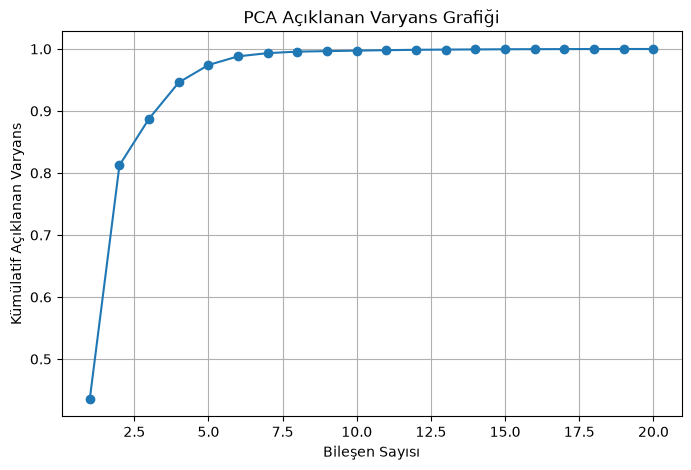

In [4]:
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(explained_variance) + 1),
    np.cumsum(explained_variance),
    marker="o"
)

plt.xlabel("Bileşen Sayısı")
plt.ylabel("Kümülatif Açıklanan Varyans")
plt.title("PCA Açıklanan Varyans Grafiği")
plt.grid(True)

plt.show()

Random Forest ile deniyoruz. 

In [5]:
rf_pca = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [6]:
pca_predictions = rf_pca.predict(X_test_pca)

In [7]:
print("="*50)
print("Random Forest + PCA")
print("="*50)

accuracy = accuracy_score(y_test, pca_predictions)
precision = precision_score(
    y_test,
    pca_predictions,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    y_test,
    pca_predictions,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    y_test,
    pca_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    pca_predictions,
    zero_division=0
))

Random Forest + PCA
Accuracy : 0.9947
Precision: 0.9947
Recall   : 0.9947
F1-Score : 0.9947

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90855
           1       0.77      0.63      0.69        78
           2       0.99      0.99      0.99      5121
           3       0.98      0.95      0.97       412
           4       0.99      0.98      0.99      9205
           5       0.94      0.94      0.94       220
           6       0.97      0.97      0.97       232
           7       0.99      0.99      0.99       317
           9       0.00      0.00      0.00         1
          10       0.99      0.99      0.99      6353
          11       0.92      0.97      0.94       236
          12       0.70      0.63      0.67        60
          13       0.00      0.00      0.00         1
          14       0.31      0.31      0.31        26

    accuracy                           0.99    113117
   macro avg     

Bu kısımda 10 ve 30 özellik halini de deniyoruz.

In [9]:
results = []

for n in [10, 20, 30]:

    pca = PCA(n_components=n, random_state=42)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_pca, y_train)

    predictions = model.predict(X_test_pca)

    results.append({
        "Bileşen Sayısı": n,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Bileşen Sayısı,Accuracy,Precision,Recall,F1-Score
0,10,0.993493,0.993426,0.993493,0.993446
1,20,0.994705,0.994654,0.994705,0.994670
2,30,0.996119,0.996046,0.996119,0.996066


In [10]:
comparison_df = pd.DataFrame({
    "Model":[
        "Random Forest",
        "RF + PCA (10)",
        "RF + PCA (20)",
        "RF + PCA (30)"
    ],
    "Accuracy":[
        0.9982,
        results_df.loc[0,"Accuracy"],
        results_df.loc[1,"Accuracy"],
        results_df.loc[2,"Accuracy"]
    ],
    "Precision":[
        0.9982,
        results_df.loc[0,"Precision"],
        results_df.loc[1,"Precision"],
        results_df.loc[2,"Precision"]
    ],
    "Recall":[
        0.9982,
        results_df.loc[0,"Recall"],
        results_df.loc[1,"Recall"],
        results_df.loc[2,"Recall"]
    ],
    "F1-Score":[
        0.9982,
        results_df.loc[0,"F1-Score"],
        results_df.loc[1,"F1-Score"],
        results_df.loc[2,"F1-Score"]
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.998200,0.998200,0.998200,0.998200
1,RF + PCA (10),0.993493,0.993426,0.993493,0.993446
2,RF + PCA (20),0.994705,0.994654,0.994705,0.994670
3,RF + PCA (30),0.996119,0.996046,0.996119,0.996066


PCA Sonuçlarının Değerlendirilmesi

Bu çalışmada PCA yöntemi kullanılarak veri setindeki özellik sayısı azaltılmış ve farklı bileşen sayılarının model performansına etkisi incelenmiştir. Boyut indirgeme sonrasında Random Forest modeli kullanılarak 10, 20 ve 30 bileşen için sınıflandırma performansı değerlendirilmiştir.

Elde edilen sonuçlara göre bileşen sayısı arttıkça model performansının da arttığı gözlemlenmiştir. 10 bileşen ile en yüksek boyut indirgeme sağlanmasına rağmen doğruluk oranında daha belirgin bir düşüş meydana gelmiştir. 20 bileşen kullanıldığında performans artarken, 30 bileşen ile elde edilen sonuçlar orijinal Random Forest modeline oldukça yakın değerler vermiştir.

Bu sonuçlar, PCA'nın veri boyutunu önemli ölçüde azaltırken sınıflandırma performansını büyük ölçüde koruyabildiğini göstermektedir. Özellikle yüksek boyutlu veri kümelerinde eğitim süresini ve hesaplama maliyetini azaltması nedeniyle PCA etkili bir boyut indirgeme yöntemi olarak değerlendirilebilir.

## Autoencoder ile Boyut İndirgeme

Bu bölümde doğrusal olmayan (non-linear) bir boyut indirgeme yöntemi olan Autoencoder kullanılacaktır. Autoencoder, giriş verisini daha düşük boyutlu bir temsile sıkıştırmayı ve bu temsilden orijinal veriyi yeniden oluşturmaya çalışmayı öğrenen yapay sinir ağı tabanlı bir modeldir.

Elde edilen düşük boyutlu veri daha sonra Random Forest modeli ile değerlendirilerek PCA ile karşılaştırılacaktır.

PCA boyut indirgeme yaparken doğrusal (linear) dönüşüm kullanıyordu. Yani matematiksel olarak yeni eksenler oluşturuyordu.

Autoencoder ne yapıyor?

Autoencoder'ın amacı da yine boyut indirgemek. Ama bunu PCA gibi matematiksel formülle değil, yapay sinir ağı kullanarak öğreniyor.

78 özellik -> Encoder -> 20 özellik -> Decoder -> 78 özellik

Yani model -> 78 -> 20 -> 78

Encoder: 78 özelliği 20 özelliğe sıkıştırıyor. 78 -> 64 -> 32 -> 20

Decoder: 20 özellikten yeniden 78 özellik oluşturmaya çalışıyor. 20 -> 32 -> 64 -> 78

Burada amaç modelin bu 20 bilgiyle tekrar 78 özelliği oluşturup oluşturamadığını kontrol etmek. Eğer oluşturabiliyorsa bu 20 özellik verinin büyük kısmını temsil ediyor diyebiliriz.

In [11]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Dense
)

from tensorflow.keras.models import Model

Autoencoder modeli ve derleme

In [12]:
input_dim = X_train.shape[1]

encoding_dim = 20

input_layer = Input(shape=(input_dim,))

encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)
encoded = Dense(encoding_dim, activation="relu")(encoded)

decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(64, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

In [13]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,650 (61.13 KB)

 Trainable params: 15,650 (61.13 KB)

 Non-trainable params: 0 (0.00 B)

Input (78) -> Dense (64) -> Dense (32) -> Dense (20)(Encoder'ın çıktısı) -> Dense (32) -> Dense (64) -> Dense (78) (Decoder'ın çıktısı)

20 nöronlu katman -> latent space (gizli temsil) veya bottleneck dediğimiz katman.

Model 78 özelliği 20 sayı ile ifade etmeyi ve sonra bu 20 sayıdan tekrar 78 özelliği üretmeye çalışıyor.

Buradaki loss (MSE) de oluşturulan yeni 78 özelliğin gerçekle ne kadar benzer olduğunu ölçüyor. Loss küçüldükçe Autoencoder daha iyi sıkıştırmayı öğrenmiş oluyor.

Normalde model.fit(X_train, y_train) yapıyorduk.

Burada ise model.fit(X_train, X_train) yazıyoruz.

Çünkü Autoencoder'ın amacı etiketi tahmin etmek değil; girişte aldığı veriyi tekrar oluşturmaktır.

Bu yüzden hedef (y) aslında yine X_train oluyor.

In [14]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 5001518776320.0000 - val_loss: 289958644416512.0000
Epoch 2/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 619634622464.0000 - val_loss: 289081430900736.0000
Epoch 3/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 457235103744.0000 - val_loss: 220041760997376.0000
Epoch 4/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 342151921664.0000 - val_loss: 170600412741632.0000
Epoch 5/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 433766858752.0000 - val_loss: 265712245407744.0000
Epoch 6/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 264101576704.0000 - val_loss: 196846404239360.0000
Epoch 7/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 150885384192.0000 - val_loss: 179967736414208.0000
Epoch 8/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 187705622528.0000 - val_loss: 255060105756672.0000
Epoch 9/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 246506438656.0000 - val_loss:

In [15]:
encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer(index=3).output
)

index=3 dememizin sebebi:

Katmanlar:

0 Input - 1 Dense64 - 2 Dense32 - 3 Dense20   ← bunu istiyoruz - 4 Dense32 - 5 Dense64 - 6 Dense78

Yani 20 boyutlu katmanı alıyoruz.

In [16]:
X_train_encoded = encoder.predict(X_train)

X_test_encoded = encoder.predict(X_test)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

14140/14140 ━━━━━━━━━━━━━━━━━━━━ 13s 939us/step
3535/3535 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
(452465, 20)
(113117, 20)


Autoencoder veriyi 78 özellikten 20 özelliğe indirmeyi öğrendi. Şimdi bu 20 özellikli veriyi Random Forest'a vererek PCA ile karşılaştıracağız.

In [17]:
rf_autoencoder = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_autoencoder.fit(X_train_encoded, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [18]:
auto_predictions = rf_autoencoder.predict(X_test_encoded)

In [19]:
print("=" * 50)
print("Random Forest + Autoencoder")
print("=" * 50)

accuracy = accuracy_score(y_test, auto_predictions)
precision = precision_score(
    y_test,
    auto_predictions,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    y_test,
    auto_predictions,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    y_test,
    auto_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    auto_predictions,
    zero_division=0
))

Random Forest + Autoencoder
Accuracy : 0.9905
Precision: 0.9905
Recall   : 0.9905
F1-Score : 0.9905

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     90855
           1       0.75      0.53      0.62        78
           2       0.99      0.99      0.99      5121
           3       0.99      0.93      0.96       412
           4       0.98      0.98      0.98      9205
           5       0.93      0.94      0.94       220
           6       0.97      0.94      0.95       232
           7       1.00      0.98      0.99       317
           9       0.00      0.00      0.00         1
          10       0.95      0.97      0.96      6353
          11       0.93      0.97      0.95       236
          12       0.69      0.60      0.64        60
          13       0.00      0.00      0.00         1
          14       0.30      0.31      0.30        26

    accuracy                           0.99    113117
   macro 

In [20]:
autoencoder_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "RF + PCA (30)",
        "RF + Autoencoder"
    ],
    "Accuracy": [
        0.9982,
        0.9961,
        accuracy
    ],
    "Precision": [
        0.9982,
        0.9960,
        precision
    ],
    "Recall": [
        0.9982,
        0.9961,
        recall
    ],
    "F1-Score": [
        0.9982,
        0.9961,
        f1
    ]
})

autoencoder_results = autoencoder_results.round(4)

autoencoder_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9982,0.9982,0.9982,0.9982
1,RF + PCA (30),0.9961,0.9960,0.9961,0.9961
2,RF + Autoencoder,0.9905,0.9905,0.9905,0.9905


Autoencoder Sonuçlarının Değerlendirilmesi

Bu çalışmada Autoencoder yöntemi kullanılarak veri seti 78 özellikten 20 özellikli bir gizli temsile (latent representation) indirgenmiştir. Elde edilen yeni özellikler üzerinde Random Forest modeli eğitilmiş ve sınıflandırma performansı değerlendirilmiştir.

Sonuçlar incelendiğinde Autoencoder ile elde edilen düşük boyutlu veri üzerinde model %99'un üzerinde doğruluk elde etmiştir. Bununla birlikte, orijinal veri ve PCA ile elde edilen sonuçlara kıyasla performansın bir miktar daha düşük olduğu görülmüştür. Bunun temel nedeni Autoencoder'ın veri sıkıştırma işlemi sırasında bazı ayırt edici bilgilerin kaybolabilmesidir.

Buna rağmen Autoencoder, doğrusal olmayan ilişkileri öğrenebilmesi sayesinde yüksek boyutlu veri kümelerinde kullanılabilecek güçlü bir boyut indirgeme yöntemidir. Özellikle daha karmaşık veri yapılarında PCA'ya alternatif olarak tercih edilebilmektedir.

## Genel Sonuç

Bu çalışmada CICIDS2017 veri seti üzerinde hem makine öğrenmesi hem de derin öğrenme tabanlı yöntemler değerlendirilmiştir. Ayrıca PCA ve Autoencoder gibi boyut indirgeme tekniklerinin sınıflandırma performansına etkisi incelenmiştir.

Makine öğrenmesi modelleri arasında Random Forest, XGBoost ve Stacking yöntemleri en yüksek performansı göstermiştir. Derin öğrenme modelleri de başarılı sonuçlar üretmiş olsa da bu veri setinde klasik makine öğrenmesi yöntemlerinin daha yüksek doğruluk oranlarına ulaştığı görülmüştür.

Boyut indirgeme yöntemleri incelendiğinde PCA'nın sınıflandırma performansını büyük ölçüde koruyarak özellik sayısını önemli ölçüde azalttığı görülmüştür. Autoencoder ise doğrusal olmayan veri ilişkilerini öğrenebilmesine rağmen bu çalışmada PCA'ya kıyasla daha düşük performans göstermiştir.

Elde edilen sonuçlar, CICIDS2017 veri seti üzerinde topluluk öğrenmesi (Ensemble Learning) yöntemlerinin oldukça başarılı olduğunu ve uygun boyut indirgeme teknikleri kullanılarak yüksek doğruluk oranlarının korunabileceğini göstermektedir.